# 지하철 혼잡도 예측 모델 (XGBoost)
서울교통공사 혼잡도 데이터를 학습해 특정 역·시각·방향의 혼잡도를 예측합니다.

**실행 순서:** 셀을 위에서부터 순서대로 실행하세요.

## 0. 라이브러리 설치 및 임포트

In [ ]:
!apt-get install -y fonts-nanum
!fc-cache -fv
!rm -rf ~/.cache/matplotlib

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 53 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [ ]:
import matplotlib.pyplot as plt
plt.rc('font', family='NanumGothic')

In [ ]:
!pip install xgboost scikit-learn pandas numpy matplotlib --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle, json
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

print('라이브러리 준비 완료')

라이브러리 준비 완료


## 1. 데이터 로드

In [ ]:
# ── Google Drive에서 불러오는 경우 ──────────────────────────────────
#from google.colab import drive
#drive.mount('/content/drive')
#FILE_PATH = '/content/drive/MyDrive/Colab Notebooks/서울교통공사_지하철혼잡도정보_20260331.csv'


# ── 직접 업로드하는 경우 ──────────────────────────────────────────
from google.colab import files
uploaded = files.upload()  # CSV 파일 선택
FILE_PATH = list(uploaded.keys())[0]


df_raw = pd.read_csv(FILE_PATH, encoding='cp949')
print(f'✅ 로드 완료: {df_raw.shape[0]}행 × {df_raw.shape[1]}열')
df_raw.head(3)

Saving 서울교통공사_지하철혼잡도정보_20260331.csv to 서울교통공사_지하철혼잡도정보_20260331 (1).csv
✅ 로드 완료: 1671행 × 44열


,요일구분,호선,역번호,출발역,상하구분,5시30분,6시00분,6시30분,7시00분,7시30분,...,20시00분,20시30분,21시00분,21시30분,22시00분,22시30분,23시00분,23시30분,00시00분,00시30분
0,평일,1호선,150,서울역,상선,8.0,20.7,23.2,41.2,67.7,...,20.5,18.6,20.0,15.0,16.5,16.8,14.0,9.2,5.9,1.3
1,평일,1호선,150,서울역,하선,11.2,11.1,17.7,24.8,41.7,...,41.0,40.4,43.3,38.0,39.5,30.2,18.7,12.8,8.6,0.0
2,평일,1호선,151,시청,상선,6.7,14.8,18.8,32.7,51.8,...,24.9,22.7,24.6,18.5,20.6,20.4,17.2,10.6,6.6,1.3


## 2. Wide → Long 변환

In [ ]:
time_cols = [c for c in df_raw.columns if '시' in c]
print(f'시간대 컬럼 수: {len(time_cols)}개  ({time_cols[0]} ~ {time_cols[-1]})')

df = df_raw.melt(
    id_vars=['요일구분', '호선', '역번호', '출발역', '상하구분'],
    value_vars=time_cols,
    var_name='시간대',
    value_name='혼잡도'
)

print(f'✅ Long 변환 완료: {len(df):,}행')
df.head(5)

시간대 컬럼 수: 39개  (5시30분 ~ 00시30분)
✅ Long 변환 완료: 65,169행


,요일구분,호선,역번호,출발역,상하구분,시간대,혼잡도
0,평일,1호선,150,서울역,상선,5시30분,8.0
1,평일,1호선,150,서울역,하선,5시30분,11.2
2,평일,1호선,151,시청,상선,5시30분,6.7
3,평일,1호선,151,시청,하선,5시30분,8.6
4,평일,1호선,152,종각,상선,5시30분,6.1


## 3. 피처 엔지니어링

In [ ]:
# ── 시간대 문자열 → 분 단위 정수 ────────────────────────────────────
def parse_time_to_minutes(t):
    """'8시30분' → 510,  '00시00분' → 1440 (자정 이후는 +1440으로 통일)"""
    t = t.strip()
    if '시30분' in t:
        h = int(t.replace('시30분', ''))
        m = 30
    else:
        h = int(t.replace('시00분', ''))
        m = 0
    total = h * 60 + m
    # 00시·00시30분(심야 막차 이후)은 1440·1470으로 보정해 연속성 유지
    if total < 330:  # 5시30분(330분) 미만 = 자정~새벽
        total += 1440
    return total

df['time_minutes'] = df['시간대'].apply(parse_time_to_minutes)

# ── 요일 피처 ────────────────────────────────────────────────────
df['is_weekday']  = (df['요일구분'] == '평일').astype(int)
df['is_saturday'] = (df['요일구분'] == '토요일').astype(int)
# is_sunday = 1 - is_weekday - is_saturday (다중공선성 방지용으로 생략)

# ── 출퇴근 시간대 플래그 ──────────────────────────────────────────
df['is_rush_am'] = ((df['time_minutes'] >= 420) & (df['time_minutes'] <= 540)).astype(int)   # 7~9시
df['is_rush_pm'] = ((df['time_minutes'] >= 1020) & (df['time_minutes'] <= 1140)).astype(int) # 17~19시

# ── 범주형 → 수치 인코딩 ─────────────────────────────────────────
line_cat = pd.CategoricalDtype(sorted(df['호선'].unique()), ordered=False)
dir_cat  = pd.CategoricalDtype(sorted(df['상하구분'].unique()), ordered=False)

df['line_encoded']      = df['호선'].astype(line_cat).cat.codes
df['direction_encoded'] = df['상하구분'].astype(dir_cat).cat.codes
# 역번호는 이미 숫자 → 그대로 사용

# ── 나중에 예측 시 역조회에 쓸 매핑 딕셔너리 저장 ───────────────────
station_to_code = df_raw.drop_duplicates('출발역').set_index('출발역')['역번호'].to_dict()
line_to_enc     = {v: k for k, v in enumerate(sorted(df['호선'].unique()))}
dir_to_enc      = {v: k for k, v in enumerate(sorted(df['상하구분'].unique()))}

print('호선 인코딩:', line_to_enc)
print('방향 인코딩:', dir_to_enc)
print(f'역 수: {len(station_to_code)}개')
print(f'\n✅ 피처 생성 완료')
df[['출발역','호선','상하구분','요일구분','시간대','time_minutes',
    'is_weekday','is_rush_am','is_rush_pm','line_encoded','direction_encoded','혼잡도']].head(5)

호선 인코딩: {'1호선': 0, '2호선': 1, '3호선': 2, '4호선': 3, '5호선': 4, '6호선': 5, '7호선': 6, '8호선': 7}
방향 인코딩: {'내선': 0, '상선': 1, '외선': 2, '하선': 3}
역 수: 245개

✅ 피처 생성 완료


,출발역,호선,상하구분,요일구분,시간대,time_minutes,is_weekday,is_rush_am,is_rush_pm,line_encoded,direction_encoded,혼잡도
0,서울역,1호선,상선,평일,5시30분,330,1,0,0,0,1,8.0
1,서울역,1호선,하선,평일,5시30분,330,1,0,0,0,3,11.2
2,시청,1호선,상선,평일,5시30분,330,1,0,0,0,1,6.7
3,시청,1호선,하선,평일,5시30분,330,1,0,0,0,3,8.6
4,종각,1호선,상선,평일,5시30분,330,1,0,0,0,1,6.1


## 4. 데이터 품질 확인

=== 혼잡도 기초 통계 ===
count    65169.00
mean        28.25
std         20.12
min          0.00
25%         13.10
50%         25.70
75%         39.40
max        147.70
Name: 혼잡도, dtype: float64

혼잡도 0인 행: 3,695개 (5.7%) → 제거 예정


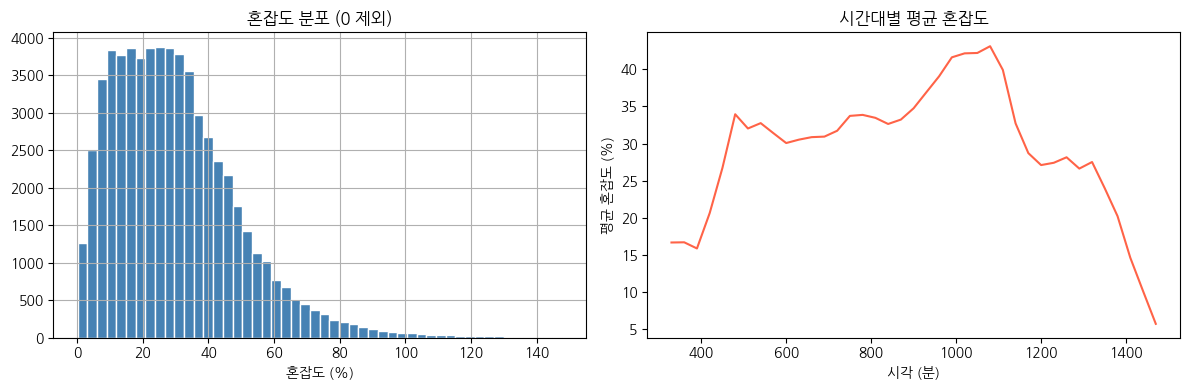

In [ ]:
print('=== 혼잡도 기초 통계 ===')
print(df['혼잡도'].describe().round(2))

# 혼잡도 0인 행 = 운행 없는 시간대 → 학습에서 제외
zero_cnt = (df['혼잡도'] == 0).sum()
print(f'\n혼잡도 0인 행: {zero_cnt:,}개 ({zero_cnt/len(df)*100:.1f}%) → 제거 예정')

# 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df[df['혼잡도'] > 0]['혼잡도'].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('혼잡도 분포 (0 제외)')
axes[0].set_xlabel('혼잡도 (%)')

df[df['혼잡도'] > 0].groupby('time_minutes')['혼잡도'].mean().plot(ax=axes[1], color='tomato')
axes[1].set_title('시간대별 평균 혼잡도')
axes[1].set_xlabel('시각 (분)')
axes[1].set_ylabel('평균 혼잡도 (%)')
plt.tight_layout()
plt.show()

## 5. 학습/테스트 데이터 분할

In [ ]:
# 혼잡도 0 제거 (운행 없는 시간대는 예측 불필요)
df_model = df[df['혼잡도'] > 0].copy()
print(f'학습 데이터: {len(df_model):,}행')

FEATURES = [
    'line_encoded',       # 호선
    '역번호',              # 역 고유 번호
    'direction_encoded',  # 상선/하선/내선/외선
    'time_minutes',       # 시각(분)
    'is_weekday',         # 평일 여부
    'is_saturday',        # 토요일 여부
    'is_rush_am',         # 오전 출근 시간대
    'is_rush_pm',         # 오후 퇴근 시간대
]
TARGET = '혼잡도'

X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'학습: {len(X_train):,}행 / 테스트: {len(X_test):,}행')

학습 데이터: 61,474행
학습: 49,179행 / 테스트: 12,295행


In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, r2_score
from itertools import product

param_grid = {
    'max_depth':        [9, 10, 11, 12],
    'learning_rate':     [0.2, 0.25, 0.3],
    'subsample':         [0.85, 0.9, 1],
    'colsample_bytree':  [1.0],
    'min_child_weight':  [4, 5, 6]
}

keys = list(param_grid.keys())
combos = list(product(*param_grid.values()))
print(f'총 조합 수: {len(combos)}개')

kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = []

for combo in combos:
    params = dict(zip(keys, combo))
    fold_maes, fold_train_maes, fold_r2s, fold_iters = [], [], [], []

    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = XGBRegressor(
            **params,
            n_estimators   = 500,
            device         = 'cpu',
            random_state   = 42,
            eval_metric    = 'mae',
            early_stopping_rounds = 30,
        )
        model.fit(
            X_tr, y_tr,
            eval_set = [(X_val, y_val)],
            verbose  = False,
        )
        y_pred_val   = model.predict(X_val)
        y_pred_train = model.predict(X_tr)

        fold_maes.append(mean_absolute_error(y_val, y_pred_val))
        fold_train_maes.append(mean_absolute_error(y_tr, y_pred_train))
        fold_r2s.append(r2_score(y_val, y_pred_val))
        fold_iters.append(model.best_iteration)

    results.append({
        **params,
        'mean_mae':       np.mean(fold_maes),
        'std_mae':        np.std(fold_maes),
        'mean_train_mae': np.mean(fold_train_maes),
        'gap':            np.mean(fold_maes) - np.mean(fold_train_maes),  # 과적합 지표
        'mean_r2':        np.mean(fold_r2s),
        'std_r2':         np.std(fold_r2s),
        'mean_iter':      int(np.mean(fold_iters)),
    })
    print(f'{params}  →  val MAE={np.mean(fold_maes):.3f}  train MAE={np.mean(fold_train_maes):.3f}  '
          f'gap={np.mean(fold_maes) - np.mean(fold_train_maes):.3f}  R²={np.mean(fold_r2s):.4f}')

results_df = pd.DataFrame(results)

총 조합 수: 108개
{'max_depth': 9, 'learning_rate': 0.2, 'subsample': 0.85, 'colsample_bytree': 1.0, 'min_child_weight': 4}  →  val MAE=2.195  train MAE=1.192  gap=1.003  R²=0.9656
{'max_depth': 9, 'learning_rate': 0.2, 'subsample': 0.85, 'colsample_bytree': 1.0, 'min_child_weight': 5}  →  val MAE=2.215  train MAE=1.243  gap=0.972  R²=0.9655
{'max_depth': 9, 'learning_rate': 0.2, 'subsample': 0.85, 'colsample_bytree': 1.0, 'min_child_weight': 6}  →  val MAE=2.216  train MAE=1.288  gap=0.928  R²=0.9661
{'max_depth': 9, 'learning_rate': 0.2, 'subsample': 0.9, 'colsample_bytree': 1.0, 'min_child_weight': 4}  →  val MAE=2.173  train MAE=1.166  gap=1.008  R²=0.9662
{'max_depth': 9, 'learning_rate': 0.2, 'subsample': 0.9, 'colsample_bytree': 1.0, 'min_child_weight': 5}  →  val MAE=2.194  train MAE=1.211  gap=0.984  R²=0.9660
{'max_depth': 9, 'learning_rate': 0.2, 'subsample': 0.9, 'colsample_bytree': 1.0, 'min_child_weight': 6}  →  val MAE=2.198  train MAE=1.260  gap=0.938  R²=0.9664
{'max_depth'

In [ ]:
results_df = pd.DataFrame(results)
results_df['mae_rank'] = results_df['mean_mae'].rank()          # 낮을수록 좋은 순위 1등
results_df['r2_rank']  = results_df['mean_r2'].rank(ascending=False)  # 높을수록 좋은 순위 1등

results_df['combined_rank'] = results_df['mae_rank'] + results_df['r2_rank']

top10 = results_df.sort_values('combined_rank').head(10)
top10

,max_depth,learning_rate,subsample,colsample_bytree,min_child_weight,mean_mae,std_mae,mean_train_mae,gap,mean_r2,std_r2,mean_iter,mae_rank,r2_rank,combined_rank
33,10,0.20,1.00,1.0,4,2.102809,0.058667,0.910617,1.192192,0.967177,0.004694,498,18.0,10.0,28.0
34,10,0.20,1.00,1.0,5,2.111086,0.044603,0.986705,1.124381,0.967566,0.004160,498,26.0,4.0,30.0
61,11,0.20,1.00,1.0,5,2.092528,0.057604,0.862581,1.229946,0.966440,0.004660,499,12.0,19.0,31.0
42,10,0.25,1.00,1.0,4,2.100765,0.064319,0.845125,1.255640,0.966971,0.005001,498,17.0,15.0,32.0
59,11,0.20,0.90,1.0,6,2.087852,0.054625,0.886424,1.201428,0.966255,0.005365,498,10.0,23.0,33.0
58,11,0.20,0.90,1.0,5,2.082919,0.059066,0.830971,1.251948,0.966031,0.005572,498,7.0,32.0,39.0
62,11,0.20,1.00,1.0,6,2.112355,0.055799,0.932976,1.179379,0.967030,0.004582,498,27.0,12.0,39.0
98,12,0.25,1.00,1.0,6,2.100571,0.056837,0.787775,1.312796,0.966182,0.004595,494,16.0,25.0,41.0
83,12,0.20,0.85,1.0,6,2.084076,0.062617,0.800936,1.283140,0.966007,0.005362,460,8.0,34.0,42.0
60,11,0.20,1.00,1.0,4,2.090611,0.055326,0.784856,1.305755,0.966003,0.004960,498,11.0,35.0,46.0


## 6. XGBoost 모델 학습

In [ ]:
model = XGBRegressor(
    n_estimators      = 500,   # 트리 수 (early stopping으로 자동 조정됨)
    max_depth         = 6,     # 트리 깊이
    learning_rate     = 0.05,  # 낮을수록 정확하지만 느림
    subsample         = 0.8,   # 행 샘플링 비율
    colsample_bytree  = 0.8,   # 피처 샘플링 비율
    min_child_weight  = 5,     # 과적합 방지
    device            = 'cuda' if __import__('subprocess').run(
                            ['nvidia-smi'], capture_output=True).returncode == 0
                        else 'cpu',
    random_state      = 42,
    eval_metric       = 'mae',
    early_stopping_rounds = 30,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print(f'\n✅ 학습 완료  |  최적 트리 수: {model.best_iteration}')

## 7. 모델 성능 평가

In [ ]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)
print(f'MAE  : {mae:.2f}% 포인트  (예측이 평균 ±{mae:.1f}% 오차)')
print(f'R²   : {r2:.4f}          (1.0에 가까울수록 좋음)')

# 실제 vs 예측 산점도
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred, alpha=0.2, s=8, color='steelblue')
axes[0].plot([0, 150], [0, 150], 'r--', lw=1)
axes[0].set_xlabel('실제 혼잡도 (%)')
axes[0].set_ylabel('예측 혼잡도 (%)')
axes[0].set_title(f'실제 vs 예측  (MAE={mae:.2f}%)')

from xgboost import plot_importance
plot_importance(model, ax=axes[1], max_num_features=8,
                importance_type='gain', title='피처 중요도 (gain 기준)')
plt.tight_layout()
plt.show()

## 8. 모델 & 매핑 딕셔너리 저장

In [ ]:
# 모델 저장
model.save_model('congestion_model.json')

# 예측 시 필요한 매핑 딕셔너리 저장
mappings = {
    'station_to_code': station_to_code,  # 역이름 → 역번호
    'line_to_enc':     line_to_enc,      # 호선명 → 인코딩 번호
    'dir_to_enc':      dir_to_enc,       # 방향명 → 인코딩 번호
    'features':        FEATURES,         # 피처 순서 고정
}
with open('congestion_mappings.json', 'w', encoding='utf-8') as f:
    json.dump(mappings, f, ensure_ascii=False, indent=2)

print('✅ 저장 완료')
print('  · congestion_model.json      ← XGBoost 모델')
print('  · congestion_mappings.json   ← 역이름/호선/방향 매핑')

# Google Drive에도 저장하려면:
# !cp congestion_model.json    /content/drive/MyDrive/
# !cp congestion_mappings.json /content/drive/MyDrive/

## 9. 예측 함수 (TMAP 연동용)

In [ ]:
def load_predictor(model_path='congestion_model.json',
                   mappings_path='congestion_mappings.json'):
    """저장된 모델과 매핑을 불러와 예측 함수를 반환합니다."""
    m = XGBRegressor()
    m.load_model(model_path)
    with open(mappings_path, encoding='utf-8') as f:
        mp = json.load(f)
    return m, mp


def predict_congestion(station_name, line, direction,
                       depart_hour, depart_minute, is_weekday,
                       model, mappings):
    """
    단일 역·시각의 혼잡도를 예측합니다.

    Parameters
    ----------
    station_name  : str  예) '서울역'
    line          : str  예) '1호선'
    direction     : str  예) '상선' / '하선' / '내선' / '외선'
    depart_hour   : int  예) 8
    depart_minute : int  예) 30
    is_weekday    : int  1=평일, 0=주말

    Returns
    -------
    float : 예측 혼잡도 (%), None = 매핑 실패
    """
    station_code = mappings['station_to_code'].get(station_name)
    line_enc     = mappings['line_to_enc'].get(line)
    dir_enc      = mappings['dir_to_enc'].get(direction)

    if any(v is None for v in [station_code, line_enc, dir_enc]):
        print(f'  ⚠️ 매핑 실패: 역={station_name}, 호선={line}, 방향={direction}')
        return None

    # 30분 슬롯으로 반올림
    raw_min = depart_hour * 60 + depart_minute
    slot    = round(raw_min / 30) * 30
    if slot < 330:
        slot += 1440  # 자정~새벽 보정

    is_saturday = 0  # TMAP 연동 시 요일 정보 받아서 처리
    is_rush_am  = int(420 <= slot <= 540)
    is_rush_pm  = int(1020 <= slot <= 1140)

    row = pd.DataFrame([{
        'line_encoded':      line_enc,
        '역번호':             station_code,
        'direction_encoded': dir_enc,
        'time_minutes':      slot,
        'is_weekday':        is_weekday,
        'is_saturday':       is_saturday,
        'is_rush_am':        is_rush_am,
        'is_rush_pm':        is_rush_pm,
    }])[mappings['features']]

    return round(float(model.predict(row)[0]), 1)


def score_route(subway_legs, depart_hour, depart_minute, is_weekday,
                model, mappings):
    """
    TMAP에서 파싱한 지하철 구간 리스트 전체의 혼잡도를 예측하고
    구간별 결과와 총점을 반환합니다.

    Parameters
    ----------
    subway_legs : list of dict
        각 원소: {'station_name': str, 'line': str,
                  'direction': str, 'elapsed_min': int}
        elapsed_min = 출발 시각 기준 이 역에 도착하기까지 경과 분

    Returns
    -------
    total_score : float  구간 혼잡도 합산
    details     : list   각 구간의 예측 결과
    """
    details = []
    base_min = depart_hour * 60 + depart_minute

    for leg in subway_legs:
        board_min  = base_min + leg['elapsed_min']
        board_h    = (board_min % 1440) // 60
        board_m    = board_min % 60

        congestion = predict_congestion(
            station_name  = leg['station_name'],
            line          = leg['line'],
            direction     = leg['direction'],
            depart_hour   = board_h,
            depart_minute = board_m,
            is_weekday    = is_weekday,
            model=model, mappings=mappings
        )
        details.append({
            **leg,
            'board_time':  f'{board_h:02d}:{board_m:02d}',
            'congestion':  congestion,
        })

    valid_scores = [d['congestion'] for d in details if d['congestion'] is not None]
    total_score  = round(sum(valid_scores), 1)
    return total_score, details


print('✅ 예측 함수 정의 완료')

## 10. 동작 테스트

In [ ]:
# ── 단일 역 예측 테스트 ───────────────────────────────────────────
result = predict_congestion(
    station_name  = '서울역',
    line          = '1호선',
    direction     = '상선',
    depart_hour   = 8,
    depart_minute = 30,
    is_weekday    = 1,
    model=model, mappings=mappings
)
print(f'서울역 1호선 상선 평일 08:30 예측 혼잡도: {result}%')

print()

# ── 경로 전체 혼잡도 테스트 (TMAP 파싱 결과 형식) ──────────────────
sample_route = [
    {'station_name': '서울역',  'line': '1호선', 'direction': '상선', 'elapsed_min': 0},
    {'station_name': '시청',    'line': '1호선', 'direction': '상선', 'elapsed_min': 2},
    {'station_name': '종각',    'line': '1호선', 'direction': '상선', 'elapsed_min': 4},
    {'station_name': '종로3가', 'line': '1호선', 'direction': '상선', 'elapsed_min': 6},
]

total, details = score_route(
    subway_legs   = sample_route,
    depart_hour   = 8,
    depart_minute = 30,
    is_weekday    = 1,
    model=model, mappings=mappings
)

print(f'{'역':<10} {'탑승시각':<8} {'혼잡도':>7}')
print('-' * 30)
for d in details:
    cong = f"{d['congestion']}%" if d['congestion'] else '매핑실패'
    print(f"{d['station_name']:<10} {d['board_time']:<8} {cong:>7}")
print('-' * 30)
print(f'총 혼잡도 점수: {total}')

NameError: name 'predict_congestion' is not defined

In [ ]:
curl --request POST \
     --url https://apis.openapi.sk.com/transit/routes/ \
     --header 'accept: application/json' \
     --header 'appKey: bAAYljxPKgakoZWpbHOJQ9BA8OMlFwXA77bGh7LS' \
     --header 'content-type: application/json' \
     --data '
{
  "startX": "126.926493082645",
  "startY": "37.6134436427887",
  "endX": "127.126936754911",
  "endY": "37.5004198786564",
  "lang": 0,
  "format": "json",
  "count": 10,
  "searchDttm": "202301011200"
}
'

SyntaxError: unterminated string literal (detected at line 6) (2060940438.py, line 6)